In [1]:
import os
os.environ["CUDA_VISIBLE_DEVICES"]="0"
os.environ['TF_FORCE_GPU_ALLOW_GROWTH'] = 'true'
os.environ['TF_CPP_MIN_LOG_LEVEL'] = '3'

In [2]:
import numpy as np
import matplotlib.pyplot as plt
import scipy
import tifffile
import tensorflow as tf

from func_file_Model import ResNet_model_paper
from func_file_Binary_star import *

### Load model

Note: During loading, tensorflow warning may be printed

In [3]:
#Load the model
model_ResNet = ResNet_model_paper(channels = 64, num_blocks_array = [3,3,3,3], 
                                  kernel_sizes=[5,7,9,11], LeakyReLU_slope=0.1, 
                                  padding="same", interpolation="bilinear", kernel_initializer="he_uniform")

#Compile and load weights
_ = model_ResNet(tf.random.normal([1, 50, 50, 1]))
model_ResNet.load_weights("DAMN_upsampling_model.keras")

I0000 00:00:1772651823.189408  885495 cuda_executor.cc:1015] successful NUMA node read from SysFS had negative value (-1), but there must be at least one NUMA node, so returning NUMA node zero. See more at https://github.com/torvalds/linux/blob/v6.0/Documentation/ABI/testing/sysfs-bus-pci#L344-L355
I0000 00:00:1772651823.214765  885495 cuda_executor.cc:1015] successful NUMA node read from SysFS had negative value (-1), but there must be at least one NUMA node, so returning NUMA node zero. See more at https://github.com/torvalds/linux/blob/v6.0/Documentation/ABI/testing/sysfs-bus-pci#L344-L355
I0000 00:00:1772651823.215081  885495 cuda_executor.cc:1015] successful NUMA node read from SysFS had negative value (-1), but there must be at least one NUMA node, so returning NUMA node zero. See more at https://github.com/torvalds/linux/blob/v6.0/Documentation/ABI/testing/sysfs-bus-pci#L344-L355
I0000 00:00:1772651823.221208  885495 cuda_executor.cc:1015] successful NUMA node read from SysFS ha

### Reconstruct binary star image

In [4]:
#Load and process the image
image_path = "Binary_star_LR.tiff"
image = tifffile.imread(image_path).astype(float)[100:150,100:150]

predicted = model_ResNet.predict(Normalize_data(image[None,:,:])[:,:,:,None]).squeeze()
predicted.shape

I0000 00:00:1772651830.230463  885704 service.cc:146] XLA service 0x7fa93c003350 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1772651830.230494  885704 service.cc:154]   StreamExecutor device (0): NVIDIA RTX A5500, Compute Capability 8.6


1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step


I0000 00:00:1772651831.969309  885704 device_compiler.h:188] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


(400, 400)

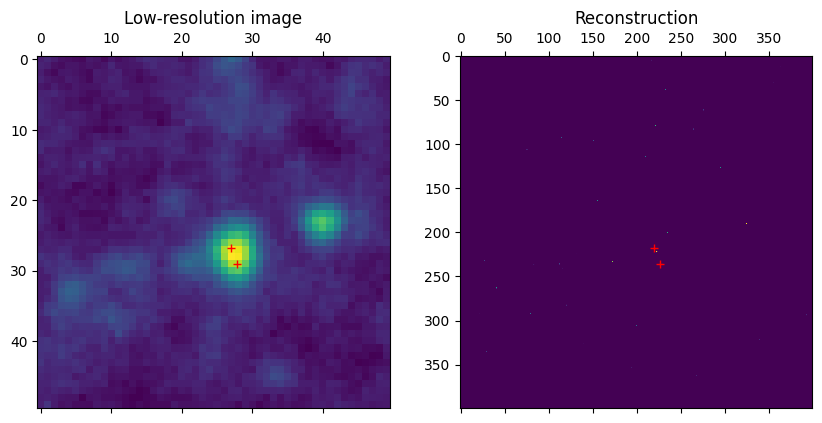

In [5]:
#Visualize LR image
plt.figure(figsize=(10,5))
plt.subplot(121)
plt.matshow(image, cmap="viridis", fignum=False)
_, _, loc_a, loc_b = Localization_cut()
plt.plot(loc_a[0], loc_a[1], '+', color="red")
plt.plot(loc_b[0], loc_b[1], '+', color="red")
plt.title("Low-resolution image")

#and its reconstruction
plt.subplot(122)
plt.matshow(predicted, cmap="viridis", fignum=False, vmax=0.35*predicted.max())
loc_a, loc_b, _, _ = Localization_cut()
plt.plot(loc_a[0], loc_a[1], '+', color="red")
plt.plot(loc_b[0], loc_b[1], '+', color="red")
plt.title("Reconstruction")

plt.show()

## Zoom to the relevant region for vizualization

In [6]:
#Specify the zoom area
zoom_vt = 210
zoom_vb = 250
zoom_hl = 205
zoom_hr = 245

predicted_zoom = predicted[210:250,205:245]

Text(0.5, 1.0, 'High-resolution zoom')

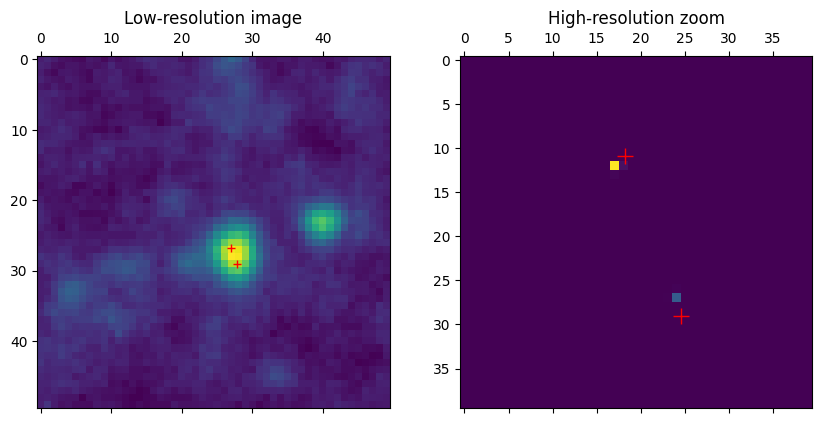

In [7]:
#Keep the LR image
plt.figure(figsize=(10,5))
plt.subplot(121)
plt.matshow(image, cmap="viridis", fignum=False)
_, _, loc_a, loc_b = Localization_cut()
plt.plot(loc_a[0], loc_a[1], '+', color="red")
plt.plot(loc_b[0], loc_b[1], '+', color="red")
plt.title("Low-resolution image")

#and zoom on the binary star
plt.subplot(122)
plt.matshow(predicted_zoom, fignum=False)
loc_a, loc_b = Localization_zoom((zoom_vt, zoom_hl))
plt.plot(loc_a[0], loc_a[1], '+', color="red", markersize=12)
plt.plot(loc_b[0], loc_b[1], '+', color="red", markersize=12)
plt.title("High-resolution zoom")

### Calculate separation

In [8]:
#The stars separation according to the ground truth table
table_sep_arcsec, table_sep_pixels = Get_star_separation()
print("Separation between the stars is", np.round(table_sep_arcsec,4), "arcsec read directly from the table")
print("Separation between the stars is", np.round(table_sep_pixels,4), "pixels of the original grid, calculated from table star coordinates\n")

pixel_size = table_sep_arcsec / table_sep_pixels   #arcsec pix⁻¹
print("Approximate pixel size", np.round(pixel_size,4), "arcsec pix⁻¹")

Separation between the stars is 0.6007 arcsec read directly from the table
Separation between the stars is 2.4034 pixels of the original grid, calculated from table star coordinates

Approximate pixel size 0.2499 arcsec pix⁻¹


In [9]:
#Estimate the center of mass of each star in the reconstructed image
radius_around_max = 3

#Estimate the COM around the first peak
upper_star_max_ver, upper_star_max_hor = np.unravel_index(np.argmax(predicted_zoom[:20,:20]), predicted_zoom[:20,:20].shape)
upper_star_COM_ver, upper_star_COM_hor = scipy.ndimage.center_of_mass(predicted_zoom[upper_star_max_ver-radius_around_max:upper_star_max_ver+radius_around_max+1, 
                                                                      upper_star_max_hor-radius_around_max:upper_star_max_hor+radius_around_max+1])
upper_star_COM_ver += upper_star_max_ver - radius_around_max
upper_star_COM_hor += upper_star_max_hor - radius_around_max
print("Estimated center of mass of the upper star is at the [" + str(np.round(upper_star_COM_ver,2)) + ", " + str(np.round(upper_star_COM_hor,2)) + "] pixel position in the zoomed reconstruction")

#Estimate the COM around the second peak
lower_star_max_ver, lower_star_max_hor = np.array((20,20)) + np.unravel_index(np.argmax(predicted_zoom[20:,20:]), predicted_zoom[20:,20:].shape)
lower_star_COM_ver, lower_star_COM_hor = scipy.ndimage.center_of_mass(predicted_zoom[lower_star_max_ver-radius_around_max:lower_star_max_ver+radius_around_max+1, 
                                                                      lower_star_max_hor-radius_around_max:lower_star_max_hor+radius_around_max+1])
lower_star_COM_ver += lower_star_max_ver - radius_around_max
lower_star_COM_hor += lower_star_max_hor - radius_around_max
print("Estimated center of mass of the lower star is at the [" + str(np.round(lower_star_COM_ver,2)) + ", " + str(np.round(lower_star_COM_hor,2)) + "] pixel position in the zoomed reconstruction")

Estimated center of mass of the upper star is at the [12.01, 17.04] pixel position in the zoomed reconstruction
Estimated center of mass of the lower star is at the [26.97, 23.98] pixel position in the zoomed reconstruction


In [10]:
#Estimate the separation between the reconstructed stars in the non-upsampled grid
estimated_sep_pixels = 1/8 * np.sqrt((upper_star_COM_ver - lower_star_COM_ver)**2 + (upper_star_COM_hor - lower_star_COM_hor)**2)
print("Estimated separation between the stars is", np.round(estimated_sep_pixels,4), "pixels of the original grid, calculated from reconstruction image")

estimated_sep_arcsec = estimated_sep_pixels * pixel_size
print("Estimated separation between the stars is", np.round(estimated_sep_arcsec,4), "arcsec")

Estimated separation between the stars is 2.0617 pixels of the original grid, calculated from reconstruction image
Estimated separation between the stars is 0.5153 arcsec
